In [7]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path

# ========== 从 batch_metrics YAML 加载结果路径 ==========
# notebook 位于 figures/PCA101A/，TSFM 根目录在两级之上
TSFM_ROOT = Path('../..')
cfg_path = TSFM_ROOT / 'setting' / 'batch_metrics_pca101a.yaml'
cfg = yaml.safe_load(cfg_path.read_text())
params = cfg.get('params', {})

seq_len = params['seq_len']       # 1536
pred_len = params['pred_len']     # 96
eval_steps = params.get('eval_steps', pred_len)  # 15
target = params['target']
results_root = TSFM_ROOT / params.get('results_root', './results')

model_dirs = {entry['name']: entry['result_dir'] for entry in cfg['model_dirs']}

def load_pred(name):
    p = results_root / model_dirs[name] / 'pred.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    arr = np.load(p)
    if arr.ndim == 3:
        arr = arr[:, :, -1]  # target column
    return arr[:, :eval_steps]  # truncate to eval_steps

def load_true(name):
    p = results_root / model_dirs[name] / 'true.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    arr = np.load(p)
    if arr.ndim == 3:
        arr = arr[:, :, -1]
    return arr[:, :eval_steps]

# ========== 加载数据 ==========
plot_true = load_true('Partial15-U')
plot_pred = load_pred('Partial15-U')

pred_zeroshot_u = load_pred('Zeroshot-U')
pred_zeroshot_m = load_pred('Zeroshot-M')
pred_zeroshot_co = load_pred('Zeroshot-Co')
pred_finetuned_u = load_pred('Finetuned-U')
pred_finetuned_co = load_pred('Finetuned-Co')
pred_partial15_u = load_pred('Partial15-U')
pred_partial15_co = load_pred('Partial15-Co')

print(f'seq_len={seq_len}  pred_len={pred_len}  eval_steps={eval_steps}')
print(f'plot_true shape: {plot_true.shape if plot_true is not None else "N/A"}')
print(f'plot_pred shape: {plot_pred.shape if plot_pred is not None else "N/A"}')

seq_len=1536  pred_len=96  eval_steps=15
plot_true shape: (193369, 15)
plot_pred shape: (193369, 15)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def build_true45_from_patches(plot_true, idx, seq_len=30, pred_len=15):
    plot_true = np.asarray(plot_true, dtype=float)
    N, P = plot_true.shape
    assert P == pred_len
    assert idx >= seq_len - 1, f"idx={idx} too small, need >= {seq_len - 1}"

    hist = np.array([plot_true[idx - seq_len + k, 0] for k in range(seq_len)], dtype=float)
    fut = plot_true[idx, :pred_len].astype(float)
    return np.concatenate([hist, fut], axis=0)

def build_pred45_from_patch(plot_pred, idx, seq_len=30, pred_len=15):
    plot_pred = np.asarray(plot_pred, dtype=float)
    pred_15 = plot_pred[idx, :pred_len].astype(float)
    pred_45 = np.full(seq_len + pred_len, np.nan, dtype=float)
    pred_45[seq_len:seq_len + pred_len] = pred_15
    return pred_45

def fault_window_plot_datetime(
    true_45,
    pred_45,
    start_time,
    freq="min",
    fault_at_idx=30,
    hlines=None,
    ylabel="PCA101A Value / (kPa)",
    title=None,
    out_path=None,
    y_min=None,
    y_max=None,
    extra_preds=None,
):
    true_45 = np.asarray(true_45, dtype=float)
    pred_45 = np.asarray(pred_45, dtype=float)

    if true_45.shape[0] != pred_45.shape[0]:
        raise ValueError("true_45 and pred_45 must have same length")
    if fault_at_idx < 0 or fault_at_idx >= true_45.shape[0]:
        raise ValueError("fault_at_idx out of range")

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7.5, "font.weight": "normal",
        "axes.labelsize": 7.5, "axes.labelweight": "normal",
        "axes.titlesize": 7.5, "axes.titleweight": "bold", "axes.linewidth": 0.8,
        "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "xtick.minor.width": 0.5, "ytick.minor.width": 0.5,
        "legend.fontsize": 7.5, "legend.frameon": False,
        "grid.linestyle": "--", "grid.linewidth": 0.5, "grid.alpha": 0.3,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })

    x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=len(true_45), freq=freq)
    fault_at = x_vals[fault_at_idx]

    fig, ax = plt.subplots(figsize=(9.5 / 2.54, 5 / 2.54))

    if extra_preds:
        for extra_data, extra_label, extra_color in extra_preds:
            extra_data = np.asarray(extra_data, dtype=float)
            ax.plot(x_vals, extra_data, label=extra_label,
                   linewidth=1.25, color=extra_color, alpha=1, zorder=1)

    ax.plot(x_vals, true_45, label="Observation",
            linewidth=1.25, color="#293890", alpha=1, zorder=2)
    ax.axvline(fault_at, label="Prognosis start",
               linestyle=":", color="#262626", linewidth=1.0, alpha=0.8, zorder=1)

    if hlines:
        for i, y in enumerate(hlines):
            ax.axhline(y, linestyle="--", color="#262626",
                      linewidth=0.8, alpha=0.7, zorder=1,
                      label="Alarm limit" if i == 0 else None)

    if y_min is not None and y_max is not None:
        ax.set_ylim(float(y_min), float(y_max))
    else:
        y_parts = [true_45, pred_45]
        if extra_preds:
            for extra_data, _, _ in extra_preds:
                y_parts.append(np.asarray(extra_data, dtype=float))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin, ymax = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax - ymin) * 0.05 if ymin != ymax else (abs(ymin) * 0.1 or 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    ax.set_xlabel("Time (HH:MM)", fontsize=7.5, fontweight="normal")
    ax.set_ylabel(ylabel, fontsize=7.5, fontweight="normal")
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc='center right', fontsize=7.5, ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    plt.subplots_adjust(left=0.15, right=0.63, top=0.88, bottom=0.15)

    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
    else:
        plt.show()


def reconstruct_signal(plot_data, start_t, end_t, pred_len=15):
    """Only take the last element (pred_len-th step) of each window to build the series."""
    plot_data = np.asarray(plot_data, dtype=float)
    N = plot_data.shape[0]
    total_len = end_t - start_t + 1

    result = np.full(total_len, np.nan)
    j = pred_len - 1

    i_lo = max(0, start_t - j)
    i_hi = min(N - 1, end_t - j)

    if i_lo <= i_hi:
        i_range = np.arange(i_lo, i_hi + 1)
        out_pos = i_range + j - start_t
        result[out_pos] = plot_data[i_range, j]

    return result


def plot_range_comparison(
    plot_true, plot_pred,
    start_t, end_t,
    pred_len=15,
    start_time=None, freq="min",
    hlines=None,
    ylabel="PCA101A Value / (kPa)",
    title=None, out_path=None,
    y_min=None, y_max=None, y_padding=0.05, y_limits=None,
    figsize_cm=(8, 6),
    show_xtick_labels=True,
    extra_preds=None,
):
    true_cont = reconstruct_signal(plot_true, start_t, end_t, pred_len=pred_len)
    pred_cont = reconstruct_signal(plot_pred, start_t, end_t, pred_len=pred_len)
    total_len = len(true_cont)

    if start_time is not None:
        x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=total_len, freq=freq)
        use_datetime = True
    else:
        x_vals = np.arange(start_t, end_t + 1)
        use_datetime = False

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7.5, "font.weight": "normal",
        "axes.labelsize": 7.5, "axes.labelweight": "normal",
        "axes.titlesize": 7.5, "axes.titleweight": "bold", "axes.linewidth": 0.8,
        "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "xtick.minor.width": 0.5, "ytick.minor.width": 0.5,
        "legend.fontsize": 7.5, "legend.frameon": False,
        "grid.linestyle": "--", "grid.linewidth": 0.5, "grid.alpha": 0.3,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })

    w_cm, h_cm = figsize_cm
    fig, ax = plt.subplots(figsize=(w_cm / 2.54, h_cm / 2.54))

    if extra_preds:
        for extra_data, extra_label, extra_color in extra_preds:
            extra_cont = reconstruct_signal(extra_data, start_t, end_t, pred_len=pred_len)
            ax.plot(x_vals, extra_cont, label=extra_label,
                   linewidth=0.8, color=extra_color, alpha=1, zorder=1)

    ax.plot(x_vals, true_cont, label="Observation",
           linewidth=0.8, color="#293890", alpha=0.9, zorder=2)

    if hlines:
        for idx_h, y in enumerate(hlines):
            ax.axhline(y, linestyle="--", color="#262626",
                      linewidth=0.8, alpha=0.7, zorder=1,
                      label="Alarm limit" if idx_h == 0 else None)

    # Y-axis range
    if y_limits is not None:
        ax.set_ylim(float(y_limits[0]), float(y_limits[1]))
    elif y_min is not None or y_max is not None:
        y_parts = [true_cont, pred_cont]
        if extra_preds:
            for extra_data, _, _ in extra_preds:
                y_parts.append(reconstruct_signal(extra_data, start_t, end_t, pred_len=pred_len))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            auto_min, auto_max = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (auto_max - auto_min) * y_padding if auto_min != auto_max else (abs(auto_min) * y_padding or 1.0)
            final_min = auto_min - pad if y_min is None else float(y_min)
            final_max = auto_max + pad if y_max is None else float(y_max)
            if final_min >= final_max:
                final_max = final_min + 1.0
            ax.set_ylim(final_min, final_max)
    else:
        y_parts = [true_cont, pred_cont]
        if extra_preds:
            for extra_data, _, _ in extra_preds:
                y_parts.append(reconstruct_signal(extra_data, start_t, end_t, pred_len=pred_len))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin_v, ymax_v = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax_v - ymin_v) * y_padding if ymin_v != ymax_v else (abs(ymin_v) * y_padding or 1.0)
            ax.set_ylim(ymin_v - pad, ymax_v + pad)

    if use_datetime:
        if total_len <= 60:
            major_interval, minor_interval = 10, 1
        elif total_len <= 180:
            major_interval, minor_interval = 30, 5
        elif total_len <= 720:
            major_interval, minor_interval = 60, 10
        elif total_len <= 1440:
            major_interval, minor_interval = 120, 30
        else:
            major_interval, minor_interval = 360, 60
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=major_interval))
        ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=minor_interval))
        if show_xtick_labels:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
        else:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        ax.set_xlabel("Time (HH:MM)", fontsize=7.5, fontweight="normal")
    else:
        if not show_xtick_labels:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        ax.set_xlabel("Time Index", fontsize=7.5, fontweight="normal")

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8, labelsize=7.5)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    ax.margins(x=0.02)
    ax.set_ylabel(ylabel, fontsize=7.5, fontweight="normal")
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc="center right", fontsize=7.5, ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    plt.tight_layout(rect=[0, 0, 0.8, 1])

    if out_path:
        fig.savefig(out_path, bbox_inches="tight", dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
        print(f"Saved to {out_path}")
    else:
        plt.show()

### Fault prognosis curve by window index

Use `build_true45_from_patches` / `build_pred45_from_patch` with a display `seq_len` (e.g. 30 min history) for zoomed-in fault window views. Note: the model's actual seq_len is 1536, but for visualization we use a shorter history window.

In [20]:
NATURE_COLORS = [                                                                                   
    '#8C8C8C',  # gray        — baseline 1                                                          
    '#5B7E96',  # steel blue  — baseline 2                                                          
    '#6A9B6A',  # sage green  — baseline 3                                                          
    '#D4A76A',  # warm sand   — baseline 4                                                          
    '#E07B54',  # burnt orange — fine-tuned                                                         
    '#C03D3D',  # deep red    — best model (last)                                                   
]

In [32]:
# Display parameters for fault window plots
display_seq = 30   # show 30 min of history (not the full 1536)
display_pred = eval_steps  # 15

idx = 10895
true_45 = build_true45_from_patches(plot_true, idx, seq_len=display_seq, pred_len=display_pred)
pred_45 = build_pred45_from_patch(plot_pred, idx, seq_len=display_seq, pred_len=display_pred)

fault_window_plot_datetime(
    true_45=true_45,
    pred_45=pred_45,
    start_time="2024-11-02 05:51:00",
    freq="min",
    fault_at_idx=display_seq,
    hlines=[205],
    title="November 2, 2024, at 05:51",
    extra_preds=[
        (build_pred45_from_patch(pred_zeroshot_u, idx, display_seq, display_pred), "Zeroshot-U", NATURE_COLORS[0]),
        (build_pred45_from_patch(pred_zeroshot_co, idx, display_seq, display_pred), "Zeroshot-Co", NATURE_COLORS[1]),
        (build_pred45_from_patch(pred_finetuned_u, idx, display_seq, display_pred), "Finetuned-U", NATURE_COLORS[2]),
        (build_pred45_from_patch(pred_finetuned_co, idx, display_seq, display_pred), "Finetuned-Co", NATURE_COLORS[3]),
        (build_pred45_from_patch(pred_partial15_u, idx, display_seq, display_pred), "Partial15-U", NATURE_COLORS[4]),
        (build_pred45_from_patch(pred_partial15_co, idx, display_seq, display_pred), "Partial15-Co", NATURE_COLORS[5]),
    ],
    out_path=f"a_fault_window_{idx}.png",
)

### Continuous range comparison (reconstruct_signal)

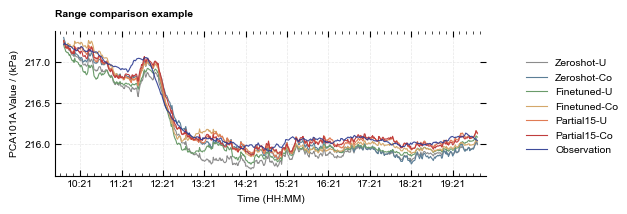

In [31]:
start_t = 111600
duration = 600
plot_range_comparison(
    plot_true=plot_true,
    plot_pred=plot_pred,
    start_t=start_t,
    end_t=start_t + duration,
    pred_len=eval_steps,
    start_time="2024-09-10 09:57:00",
    freq="min",
    show_xtick_labels=True,
    # hlines=[205],
    title="Range comparison example",
    figsize_cm=(16, 5.5),
    ylabel="PCA101A Value / (kPa)",
    extra_preds=[
        (pred_zeroshot_u, "Zeroshot-U", NATURE_COLORS[0]),
        (pred_zeroshot_co, "Zeroshot-Co", NATURE_COLORS[1]),
        (pred_finetuned_u, "Finetuned-U", NATURE_COLORS[2]),
        (pred_finetuned_co, "Finetuned-Co", NATURE_COLORS[3]),
        (pred_partial15_u, "Partial15-U", NATURE_COLORS[4]),
        (pred_partial15_co, "Partial15-Co", NATURE_COLORS[5]),
    ],
    # out_path=f"a_range_{start_t}_{duration}.png",
)